# Stabilitet

Stabilitet er et kraftsystems evne til å motstå forstyrrelser og utvikle tilstrekkelige gjenopprettende krefter til å opprettholde en likevektstilstand. Et system er stabilt dersom synkronmaskinene forblir i synkronisme etter en forstyrrelse.

Generelt deles kraftsystemstabilitet inn i to hovedkategorier: **stasjonær stabilitet (steady-state stability)** og **transient stabilitet (transient stability)**.

**Stasjonær stabilitet** beskriver systemets evne til å opprettholde synkronisme ved små og gradvise endringer i last eller produksjon, for eksempel ved langsomme effektendringer. I en utvidet betydning omfatter stasjonær stabilitet også **dynamisk stabilitet**. Dynamisk stabilitet beskriver systemets respons på små forstyrrelser som virker over lengre tid, der automatiske reguleringssystemer som spenningsregulatorer (AVR) og turbinregulatorer påvirker stabilitetsforløpet.

**Transient stabilitet** beskriver systemets evne til å opprettholde synkronisme etter store og plutselige forstyrrelser, som kortslutninger, utkobling av transmisjonslinjer eller bortfall av generatorer.

Det er et økende behov for transientstabilitetsanalyser i moderne kraftsystemer på grunn av økende kompleksitet og høyere utnyttelsesgrad av nettet. Analysene brukes for å verifisere at kraftsystemet opprettholder synkronisme etter alvorlige feil og forstyrrelser. Resultatene er viktige ved planlegging av ny produksjon og transmisjon, samt ved fastsettelse av verninnstillinger, kritisk feilklareringstid, spenningsnivåer og maksimal overføringskapasitet

### Fysisk tolkning av MMF- og spenningsvektorene

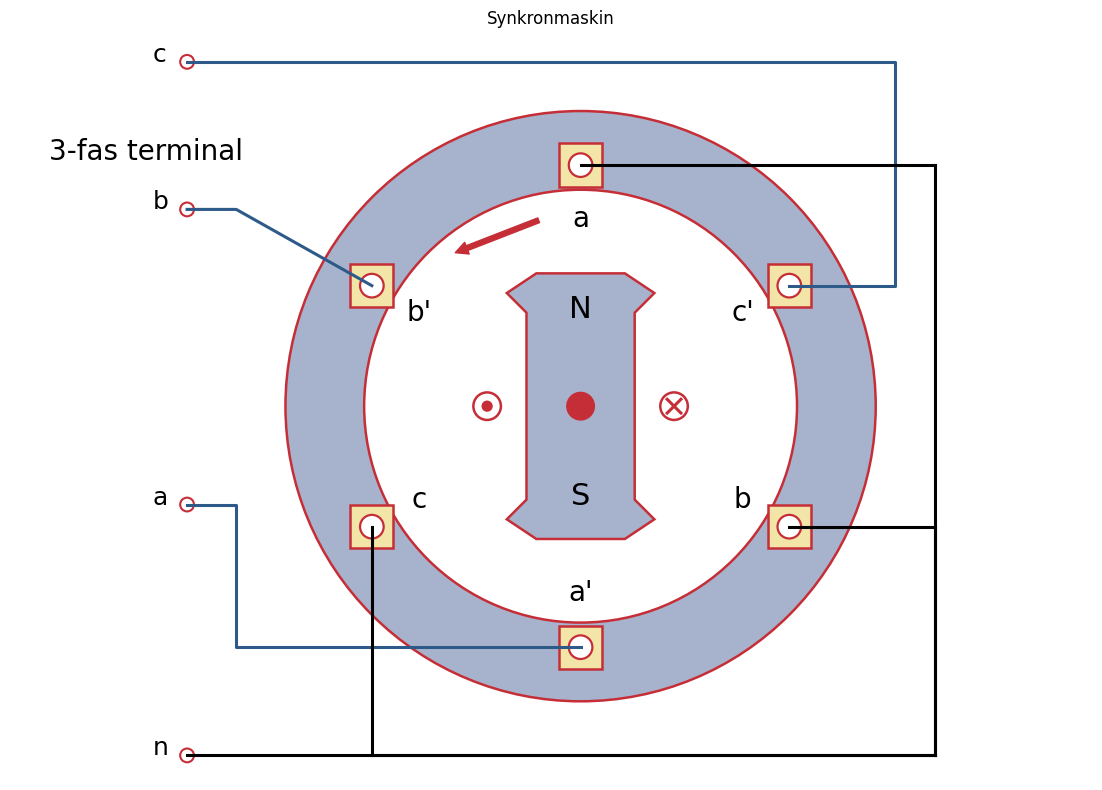

In [43]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
ax.text(0,0.9,'N',ha='center',fontsize=22)
ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)

    # Venstre: dot
ax.add_patch(Circle((-0.95, 0), 0.14,
                    facecolor='white',
                    edgecolor=RED, lw=1.8))
ax.add_patch(Circle((-0.95, 0), 0.05,
                    facecolor=RED,
                    edgecolor=RED))

# Høyre: kryss
ax.add_patch(Circle((0.95, 0), 0.14,
                    facecolor='white',
                    edgecolor=RED, lw=1.8))
ax.plot([0.88, 1.02], [0.07, -0.07],
        color=RED, lw=2.2)
ax.plot([0.88, 1.02], [-0.07, 0.07],
        color=RED, lw=2.2)

ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

Rotorens likestrømseksitasjon skaper rotor-MMF-en ifølge Ampères lov

$$
\oint \mathbf{H}\cdot d\mathbf{l}=N_fI_f,
$$

som for rotorviklingen kan skrives som

$$
F_r=N_fI_f.
$$

$F_r$ setter opp flukslinjene $\phi_r$. Magnetiske flukslinjer danner lukkede baner: $$\vec{\nabla} \cdot \mathbf{B} = 0$$

Rotorfluksen $\Phi_r$ følger den magnetiske kretsen gjennom rotorens nordpol $(\mathcal{R}_{rp})$, luftgapet $(\mathcal{R}_{g1})$, statorkjernen $(\mathcal{R}_{s})$, det motsatte luftgapet $(\mathcal{R}_{g2})$ og tilbake til rotorens sydpol $(\mathcal{R}_{sp})$.

$$\mathcal{R}_{tot} = \mathcal{R}_{rp} + \mathcal{R}_{g1} + \mathcal{R}_{s} + \mathcal{R}_{g2} + \mathcal{R}_{sp}$$
Rotorfluksen er gitt ved den magnetiske kretsloven  $$\Phi_r = \frac{F_r}{\mathcal{R}_{tot}}, $$ hvor $F_r = N_f I_f$ er rotorens magnetomotoriske kraft (MMF).

Rotor-MMF-en etablerer rotorfluksen

$$
\Phi_r \propto F_r,
$$

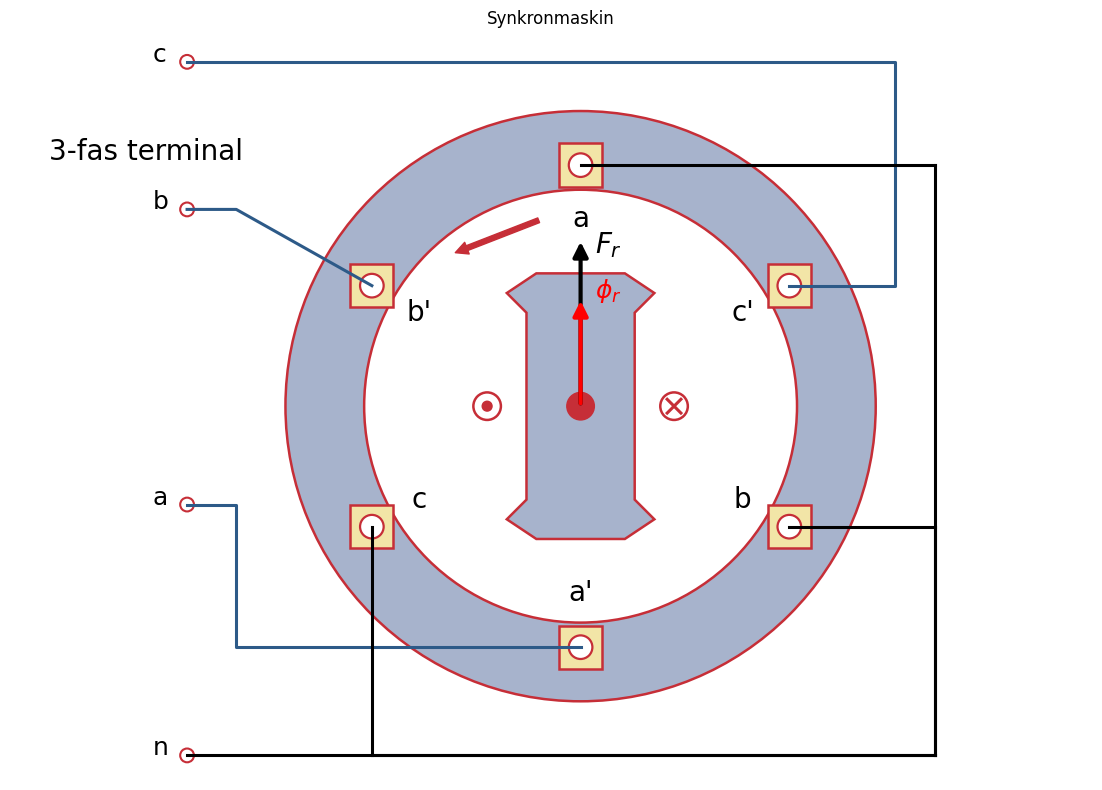

In [51]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
#ax.text(0,0.9,'N',ha='center',fontsize=22)
#ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)

    # Venstre: dot
ax.add_patch(Circle((-0.95, 0), 0.14,
                    facecolor='white',
                    edgecolor=RED, lw=1.8))
ax.add_patch(Circle((-0.95, 0), 0.05,
                    facecolor=RED,
                    edgecolor=RED))

# Høyre: kryss
ax.add_patch(Circle((0.95, 0), 0.14,
                    facecolor='white',
                    edgecolor=RED, lw=1.8))
ax.plot([0.88, 1.02], [0.07, -0.07],
        color=RED, lw=2.2)
ax.plot([0.88, 1.02], [-0.07, 0.07],
        color=RED, lw=2.2)

# Fr-vektor mot a-aksen (90 grader)
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (0, 1.7),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='black'
    )
)

ax.text(0.15, 1.55,
        r'$F_r$',
        color='black',
        fontsize=20)

# phi_r
ax.add_patch(FancyArrowPatch(
(0,0), (0,1.1),
arrowstyle='-|>',
mutation_scale=22,
lw=3,
color='red'
))
ax.text(0.15,1.1,r'$\phi_r$',color='red',fontsize=18)

ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

Når $\phi_r$ lukker sin bane, kobles statorviklingene til gjennom flukskoblingen $\lambda_r$. Ved rotasjon induseres den interne genererte spenningen $E$ i henhold til Faradays lov

$$
E=-\frac{d\lambda_r}{dt}.
$$

$$
E(t)
=
-\frac{d\lambda_r}{dt}
=
\omega\Lambda_{\max}\sin(\omega t).
$$

der $\lambda$ er hvor mye av fluksen $\Phi$, som faktisk kobler seg til viklingen; flukskoblingen.

For sinusformede størrelser er den induserte spenningen i kvadratur med fluksen. 

Dermed $E$ er $90^{\circ}$ etter $F_r$.

Sammenhengen kan oppsummeres som:
$$
I_f \rightarrow F_r \rightarrow \Phi_r \rightarrow \lambda_r \rightarrow E.
$$

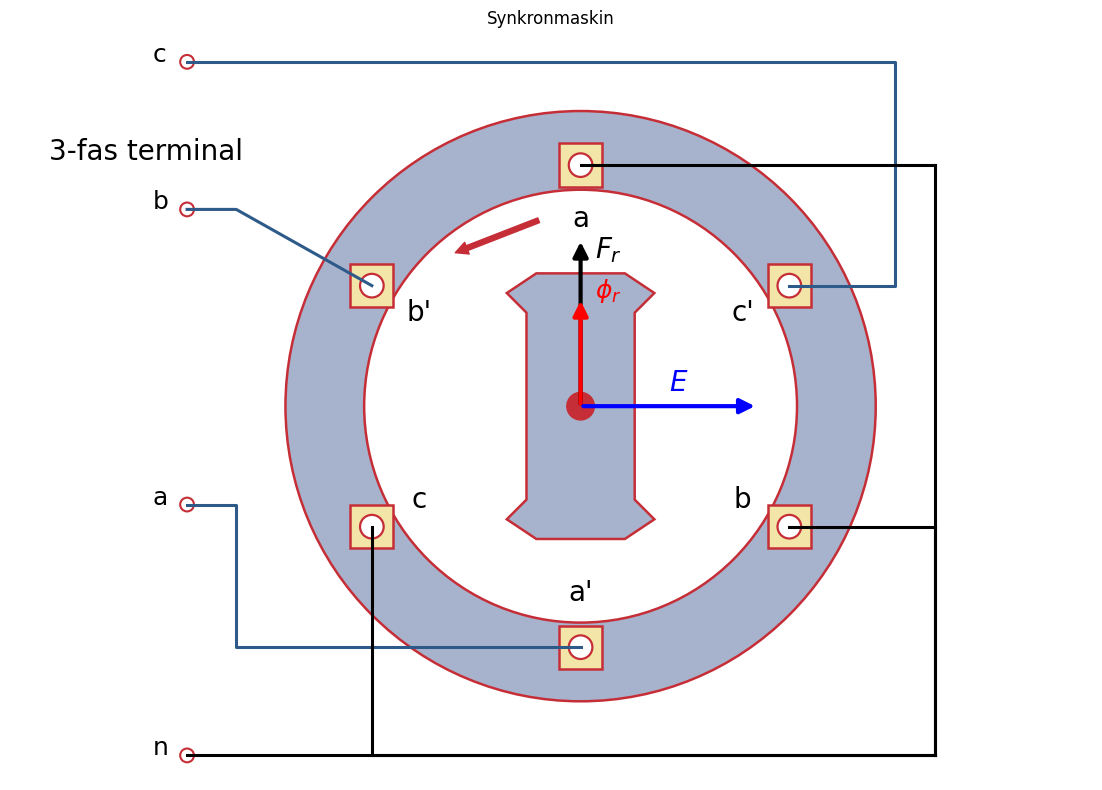

In [61]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
#ax.text(0,0.9,'N',ha='center',fontsize=22)
#ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)


# Fr-vektor mot a-aksen (90 grader)
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (0, 1.7),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='black'
    )
)

ax.text(0.15, 1.5,
        r'$F_r$',
        color='black',
        fontsize=20)

# phi_r
ax.add_patch(FancyArrowPatch(
(0,0), (0,1.1),
arrowstyle='-|>',
mutation_scale=22,
lw=3,
color='red'
))
ax.text(0.15,1.1,r'$\phi_r$',color='red',fontsize=18)

# E-vektor 90 grader foran Fr
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (1.8, 0),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='blue'
    )
)

ax.text(0.9, 0.15,
        r'$E$',
        color='blue',
        fontsize=20)


ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

### Lasttilkobling
Når generatoren belastes, flyter armaturstrømmen $I_a$ i statorviklingene. Ifølge Ampères lov etablerer strømmen en stator-MMF
Når en last kobles til, flyter armaturstrømmen $I_a$. Ifølge Ampères lov skaper denne strømmen et eget magnetfelt:
$$
F_s = N_a I_a,
$$

der $N_a$ er det effektive antallet viklinger i armaturet. Størrelsen og retningen til $F_s$ bestemmes derfor direkte av armaturstrømmen $I_a$:

$$
F_s \propto I_a.
$$

Dette feltet påvirker rotorens hovedfelt. Denne påvirkningen kalles armaturreaksjon.

Den resulterende MMF-en blir

$$
F_{sr}=F_r+F_s.
$$

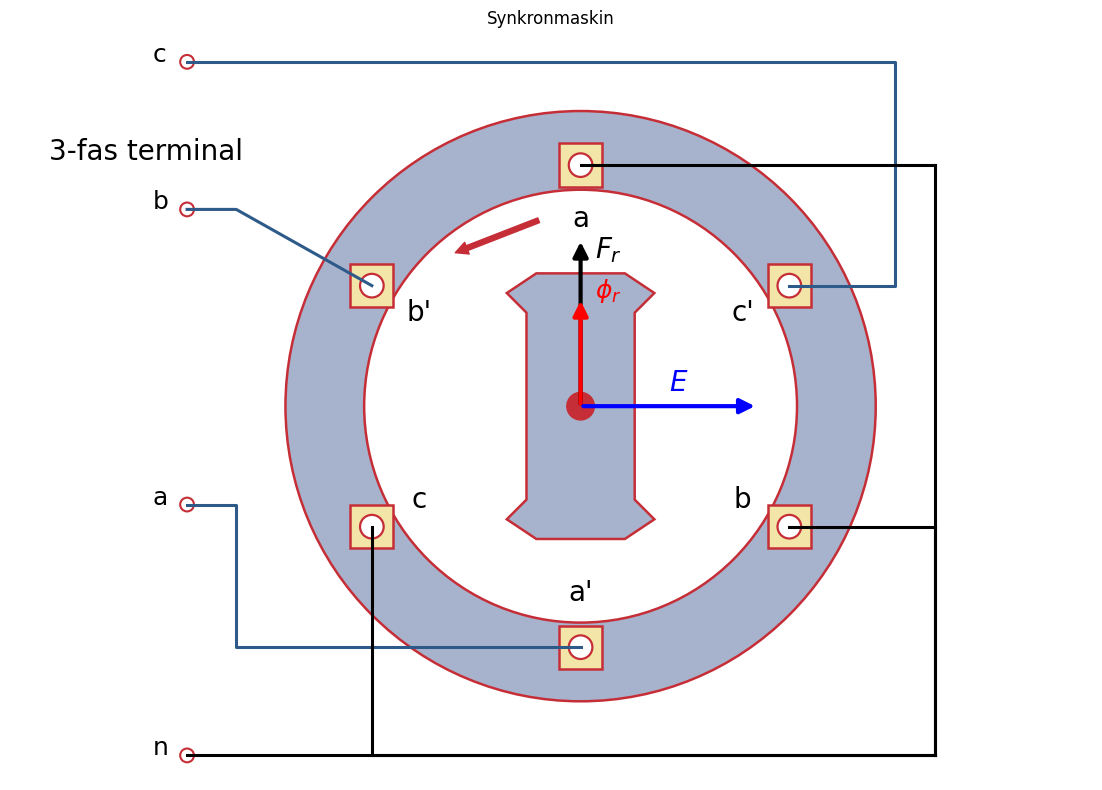

In [63]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
#ax.text(0,0.9,'N',ha='center',fontsize=22)
#ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)


# Fr-vektor mot a-aksen (90 grader)
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (0, 1.7),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='black'
    )
)

ax.text(0.15, 1.5,
        r'$F_r$',
        color='black',
        fontsize=20)

# phi_r
ax.add_patch(FancyArrowPatch(
(0,0), (0,1.1),
arrowstyle='-|>',
mutation_scale=22,
lw=3,
color='red'
))
ax.text(0.15,1.1,r'$\phi_r$',color='red',fontsize=18)

# E-vektor 90 grader foran Fr
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (1.8, 0),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='blue'
    )
)

ax.text(0.9, 0.15,
        r'$E$',
        color='blue',
        fontsize=20)


ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

## Armaturreaksjon

Denne prosessen kalles **armaturreaksjon**, som er påvirkningen statorstrømmen har på generatorens hovedfelt.

Armaturreaksjonen kan beskrives som

$$
I_a
\rightarrow
F_s
\rightarrow
F_{sr}.
$$

Det resulterende luftgapfeltet etablerer den resulterende fluksen

$$
\Phi_{sr}\propto F_{sr},
$$

og den tilhørende flukskoblingen

$$
\lambda_{sr}\propto \Phi_{sr}.
$$

Ifølge Faradays lov induserer denne flukskoblingen spenningen

$$
E_{sr}
=
-\frac{d\lambda_{sr}}{dt},
$$

slik at

$$
E_{sr}\propto F_{sr}.
$$

Sammenhengen kan oppsummeres som

$$
I_a
\rightarrow
F_s
\rightarrow
F_{sr}
\rightarrow
\Phi_{sr}
\rightarrow
\lambda_{sr}
\rightarrow
E_{sr}.
$$



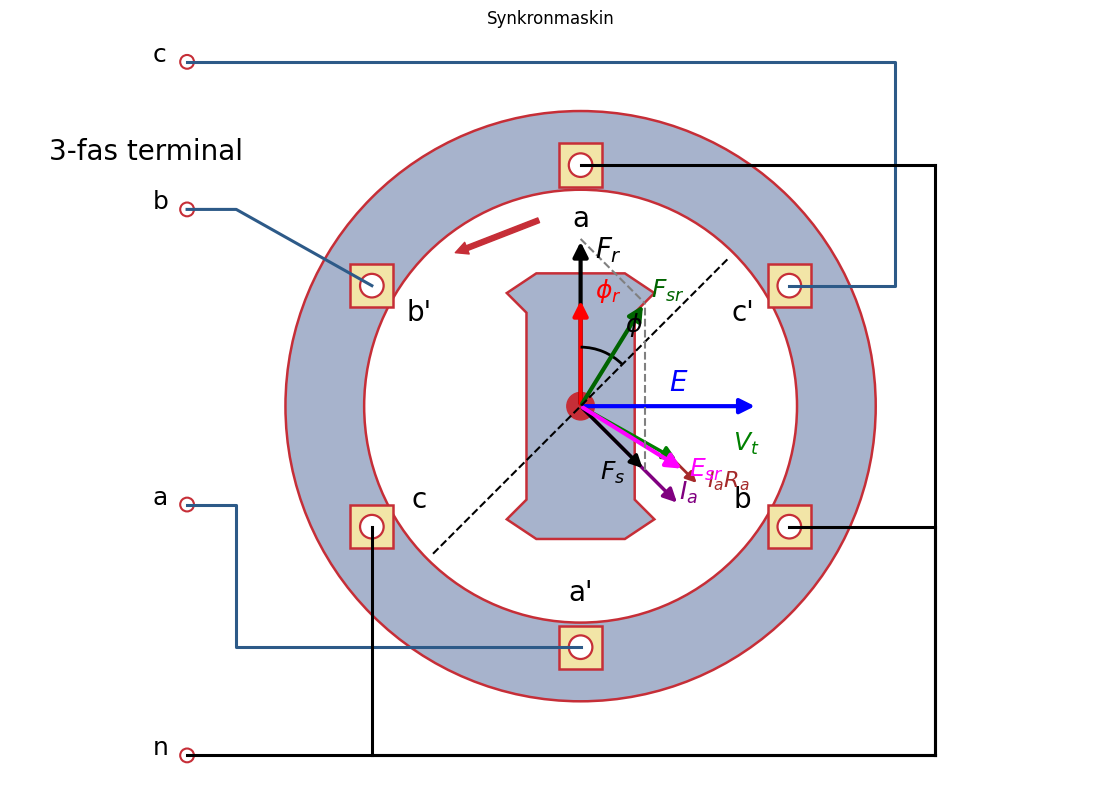

In [114]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
#ax.text(0,0.9,'N',ha='center',fontsize=22)
#ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)


# Fr-vektor mot a-aksen (90 grader)
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (0, 1.7),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='black'
    )
)

ax.text(0.15, 1.5,
        r'$F_r$',
        color='black',
        fontsize=20)

# phi_r
ax.add_patch(FancyArrowPatch(
(0,0), (0,1.1),
arrowstyle='-|>',
mutation_scale=22,
lw=3,
color='red'
))
ax.text(0.15,1.1,r'$\phi_r$',color='red',fontsize=18)

# E-vektor 90 grader foran Fr
ax.add_patch(
    FancyArrowPatch(
        (0, 0),
        (1.8, 0),
        arrowstyle='-|>',
        mutation_scale=22,
        lw=3,
        color='blue'
    )
)

ax.text(0.9, 0.15,
        r'$E$',
        color='blue',
        fontsize=20)



# I_a litt under E
ax.add_patch(FancyArrowPatch(
    (0,0), (1,-1),
    arrowstyle='-|>',
    mutation_scale=20,
    lw=2.5,
    color='purple'
))
ax.text(1,-0.95,r'$I_a$',color='purple',fontsize=18)

# F_s i samme retning som I_a
ax.add_patch(FancyArrowPatch(
    (0,0), (0.65,-0.65),
    arrowstyle='-|>',
    mutation_scale=18,
    lw=2.5,
    color='black'
))
ax.text(0.2,-0.75,r'$F_s$',color='black',fontsize=18)

# Stiplet linje vinkelrett på Ia
ax.plot(
    [-1.5, 1.5],
    [-1.5, 1.5],
    'k--',
    lw=1.5
)

from matplotlib.patches import Arc

# Vinkel phi mellom ortogonal på Ia og Fr
arc = Arc(
    (0, 0),          # sentrum
    1.2, 1.2,        # bredde/høyde
    angle=0,
    theta1=45,       # ortogonal til Ia
    theta2=90,       # Fr
    color='black',
    lw=2
)
ax.add_patch(arc)

ax.text(
    0.45, 0.75,
    r'$\phi$',
    fontsize=18
)

# F_sr = F_r + F_s
ax.add_patch(FancyArrowPatch(
    (0,0), (0.65,1.05),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='darkgreen'
))

ax.text(
    0.72, 1.10,
    r'$F_{sr}$',
    color='darkgreen',
    fontsize=18
)

# Flytt Fs til spissen av Fr
ax.plot(
    [0, 0.65],
    [1.7, 1.05],
    '--',
    color='gray',
    lw=1.5
)

# Flytt Fr til spissen av Fs
ax.plot(
    [0.65, 0.65],
    [-0.65, 1.05],
    '--',
    color='gray',
    lw=1.5
)

# V_t mellom E og I_a
ax.add_patch(FancyArrowPatch(
    (0,0), (1,-0.56),   # ca -20 grader
    arrowstyle='-|>',
    mutation_scale=20,
    lw=2.5,
    color='green'
))

ax.text(
    1.55,-0.45,
    r'$V_t$',
    color='green',
    fontsize=18
)

# I_a R_a fra spissen av V_t (parallell med I_a)
ax.add_patch(FancyArrowPatch(
    (0.9, -0.5),
    (1.2, -0.8),
    arrowstyle='-|>',
    mutation_scale=16,
    lw=2,
    color='brown'
))

ax.text(
    1.28, -0.83,
    r'$I_aR_a$',
    color='brown',
    fontsize=16
)

# E_sr 90 grader foran F_sr
ax.add_patch(FancyArrowPatch(
    (0,0),
    (1.05,-0.65),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='magenta'
))

ax.text(
    1.10,-0.72,
    r'$E_{sr}$',
    color='magenta',
    fontsize=18
)

ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

Den resulterende luftgapfluksen $F_{sr}$ induserer spenningen $E_{sr}$. En del av den magnetiske fluksen opptrer imidlertid som lekkfluks og bidrar ikke til den gjensidige koblingen mellom rotor og stator. Effekten av lekkfluksen representeres ved lekkreaktansen $X_l$, som gir spenningsfallet $jX_lI_a$. Dette spenningsfallet reduserer den tilgjengelige terminalspenningen $V_t$.

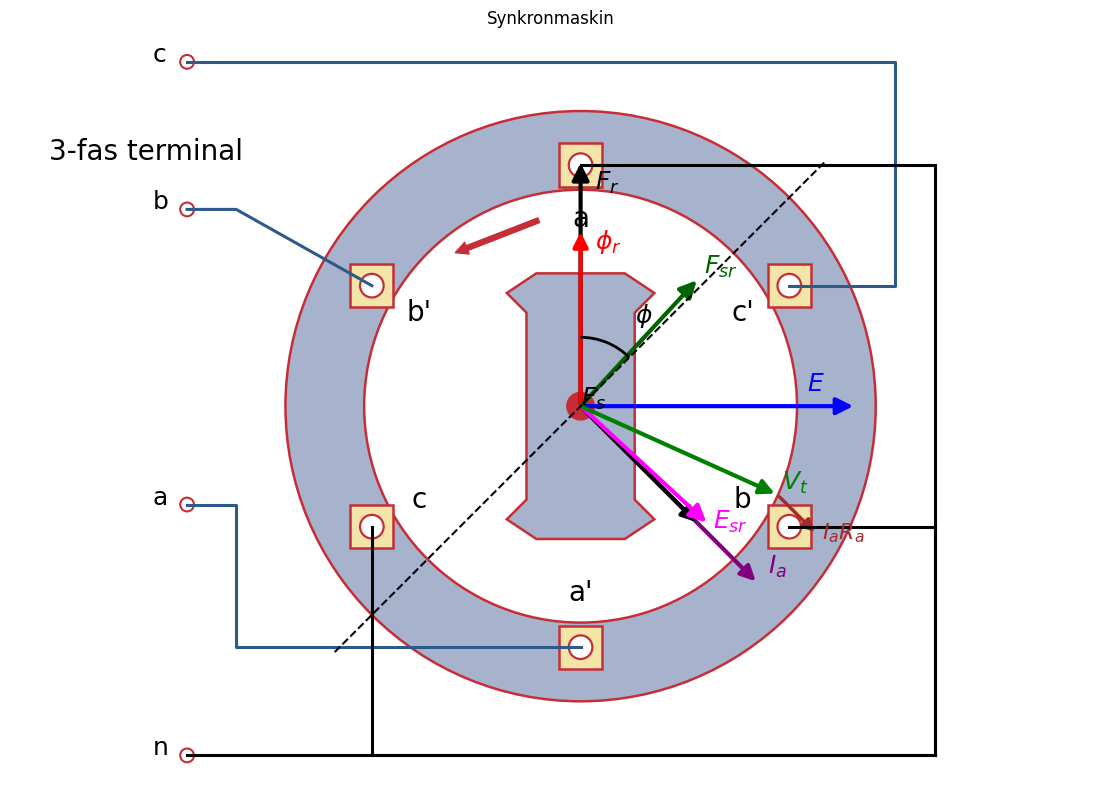

In [118]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
#ax.text(0,0.9,'N',ha='center',fontsize=22)
#ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    display_label = {
    'a': 'c',
    'c': 'a',
    "a'": "c'",
    "c'": "a'"
    }.get(label, label)

    ax.text(1.9*np.cos(t),1.9*np.sin(t),display_label,
        fontsize=20,ha='center',va='center')

terms={'c':(-4,3.5),'b':(-4,2),'a':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)

# Senter for fasordiagrammet
cx, cy = 0, 0.0

# Fr
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx,cy+2.5),
    arrowstyle='-|>',
    mutation_scale=25,
    lw=3,
    color='black'
))
ax.text(cx+0.15, cy+2.2, r'$F_r$', fontsize=18)

# phi_r
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx,cy+1.8),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='red'
))
ax.text(cx+0.15, cy+1.6, r'$\phi_r$', color='red', fontsize=18)

# E
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+2.8,cy),
    arrowstyle='-|>',
    mutation_scale=25,
    lw=3,
    color='blue'
))
ax.text(cx+2.3, cy+0.15, r'$E$', color='blue', fontsize=18)

# Ia
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+1.8,cy-1.8),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='purple'
))
ax.text(cx+1.9, cy-1.7, r'$I_a$', color='purple', fontsize=18)

# Fs
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+1.2,cy-1.2),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='black'
))
ax.text(cx+0., cy-0, r'$F_s$', fontsize=18)

# Fsr = Fr + Fs
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+1.2,cy+1.3),
    arrowstyle='-|>',
    mutation_scale=25,
    lw=3,
    color='darkgreen'
))
ax.text(cx+1.25, cy+1.35, r'$F_{sr}$',
        color='darkgreen', fontsize=18)

# E_sr 90° foran Fsr
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+1.3,cy-1.2),
    arrowstyle='-|>',
    mutation_scale=25,
    lw=3,
    color='magenta'
))
ax.text(cx+1.35, cy-1.25,
        r'$E_{sr}$',
        color='magenta',
        fontsize=18)

# Vt mellom E og Ia
ax.add_patch(FancyArrowPatch(
    (cx,cy), (cx+2.0,cy-0.9),
    arrowstyle='-|>',
    mutation_scale=22,
    lw=3,
    color='green'
))
ax.text(cx+2.05, cy-0.85,
        r'$V_t$',
        color='green',
        fontsize=18)

# IaRa fra Vt
ax.add_patch(FancyArrowPatch(
    (cx+2.0,cy-0.9),
    (cx+2.4,cy-1.3),
    arrowstyle='-|>',
    mutation_scale=18,
    lw=2.5,
    color='brown'
))
ax.text(cx+2.45, cy-1.35,
        r'$I_aR_a$',
        color='brown',
        fontsize=16)

# Stiplet linje ortogonal på Ia
ax.plot(
    [cx-2.5, cx+2.5],
    [cy-2.5, cy+2.5],
    'k--',
    lw=1.5
)

# Phi-vinkel
from matplotlib.patches import Arc

ax.add_patch(
    Arc(
        (cx,cy),
        1.4,1.4,
        theta1=45,
        theta2=90,
        lw=2,
        color='black'
    )
)

ax.text(
    cx+0.55,
    cy+0.85,
    r'$\phi$',
    fontsize=18
)

ax.text(-5.4,2.5,'3-fas terminal',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Synkronmaskin')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()

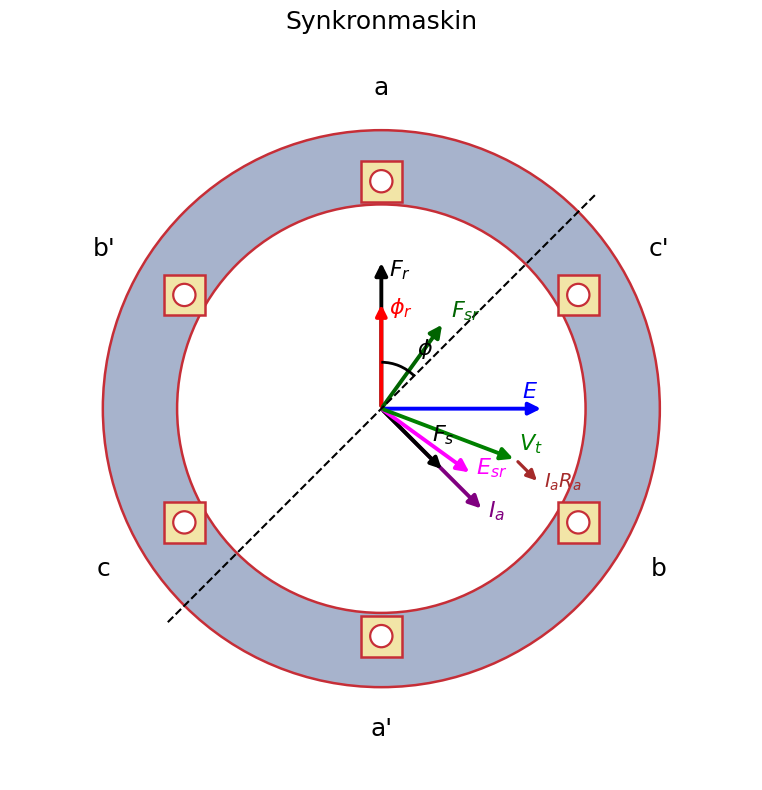

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import (
    Circle, Polygon, Rectangle,
    FancyArrowPatch, Arc
)

fig, ax = plt.subplots(figsize=(10,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE   = '#2d5a88'
RED    = '#c62e37'
STATOR = '#a7b3cc'
COIL   = '#f2e5a7'

# =====================================================
# STATOR
# =====================================================

ax.add_patch(
    Circle((0,0), 3.0,
           facecolor=STATOR,
           edgecolor=RED,
           lw=1.8)
)

ax.add_patch(
    Circle((0,0), 2.2,
           facecolor='white',
           edgecolor=RED,
           lw=1.8)
)



# =====================================================
# STATORVIKLINGER
# =====================================================

angles = [90, 30, -30, -90, -150, 150]
labels = ['c', "a'", 'b', "c'", 'a', "b'"]

label_radius = 3.45

for ang, label in zip(angles, labels):

    t = np.radians(ang)

    x = 2.45*np.cos(t)
    y = 2.45*np.sin(t)

    ax.add_patch(
        Rectangle(
            (x-0.22, y-0.22),
            0.44,
            0.44,
            facecolor=COIL,
            edgecolor=RED,
            lw=1.8
        )
    )

    ax.add_patch(
        Circle(
            (x,y),
            0.12,
            facecolor='white',
            edgecolor=RED,
            lw=1.6
        )
    )

    display_label = {
        'a': 'c',
        'c': 'a',
        "a'": "c'",
        "c'": "a'"
    }.get(label, label)

    # Flyttet utenfor statoren
    ax.text(
        label_radius*np.cos(t),
        label_radius*np.sin(t),
        display_label,
        fontsize=18,
        ha='center',
        va='center'
    )

# =====================================================
# FASORDIAGRAM
# =====================================================

cx = 0.0
cy = 0.0

# -----------------------------------------------------
# Fr
# -----------------------------------------------------

Fr_end = (0, 1.6)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Fr_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='black'
    )
)

ax.text(
    0.08,
    1.42,
    r'$F_r$',
    fontsize=16
)

# -----------------------------------------------------
# phi_r
# -----------------------------------------------------

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        (0,1.15),
        arrowstyle='-|>',
        mutation_scale=16,
        lw=2.8,
        color='red'
    )
)

ax.text(
    0.08,
    1.02,
    r'$\phi_r$',
    color='red',
    fontsize=16
)

# -----------------------------------------------------
# E
# -----------------------------------------------------

E_end = (1.75, 0)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        E_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='blue'
    )
)

ax.text(
    1.52,
    0.12,
    r'$E$',
    color='blue',
    fontsize=16
)

# -----------------------------------------------------
# Ia
# -----------------------------------------------------

theta = np.radians(-45)

Ia_mag = 1.55

Ia_end = (
    Ia_mag*np.cos(theta),
    Ia_mag*np.sin(theta)
)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Ia_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='purple'
    )
)

ax.text(
    Ia_end[0]+0.05,
    Ia_end[1]-0.08,
    r'$I_a$',
    color='purple',
    fontsize=16
)

# -----------------------------------------------------
# Fs
# -----------------------------------------------------

Fs_mag = 0.95

Fs_end = (
    Fs_mag*np.cos(theta),
    Fs_mag*np.sin(theta)
)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Fs_end,
        arrowstyle='-|>',
        mutation_scale=16,
        lw=2.8,
        color='black'
    )
)

ax.text(
    0.55,
    -0.35,
    r'$F_s$',
    fontsize=16
)

# -----------------------------------------------------
# Fsr = Fr + Fs
# -----------------------------------------------------

Fsr_end = (
    Fr_end[0] + Fs_end[0],
    Fr_end[1] + Fs_end[1]
)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Fsr_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='darkgreen'
    )
)

ax.text(
    Fsr_end[0] + 0.08,
    Fsr_end[1] + 0.05,
    r'$F_{sr}$',
    color='darkgreen',
    fontsize=16
)

# -----------------------------------------------------
# Esr (90° foran Fsr)
# -----------------------------------------------------

x, y = Fsr_end

Esr_end = (y, -x)

Esr_mag = np.hypot(*Esr_end)

scale = 1.20 / Esr_mag

Esr_end = (
    Esr_end[0]*scale,
    Esr_end[1]*scale
)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Esr_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='magenta'
    )
)

ax.text(
    Esr_end[0] + 0.05,
    Esr_end[1],
    r'$E_{sr}$',
    color='magenta',
    fontsize=16
)

# -----------------------------------------------------
# Vt
# -----------------------------------------------------

Vt_end = (1.45, -0.55)

ax.add_patch(
    FancyArrowPatch(
        (cx,cy),
        Vt_end,
        arrowstyle='-|>',
        mutation_scale=18,
        lw=2.8,
        color='green'
    )
)

ax.text(
    1.48,
    -0.45,
    r'$V_t$',
    color='green',
    fontsize=16
)

# -----------------------------------------------------
# IaRa
# -----------------------------------------------------

Ra_end = (
    Vt_end[0] + 0.35*np.cos(theta),
    Vt_end[1] + 0.35*np.sin(theta)
)

ax.add_patch(
    FancyArrowPatch(
        Vt_end,
        Ra_end,
        arrowstyle='-|>',
        mutation_scale=15,
        lw=2.3,
        color='brown'
    )
)

ax.text(
    Ra_end[0] + 0.05,
    Ra_end[1] - 0.05,
    r'$I_aR_a$',
    color='brown',
    fontsize=14
)

# -----------------------------------------------------
# Normal til Ia
# -----------------------------------------------------

s = 2.3

ax.plot(
    [-s, s],
    [-s, s],
    'k--',
    lw=1.5
)

# -----------------------------------------------------
# phi-vinkel
# -----------------------------------------------------

ax.add_patch(
    Arc(
        (0,0),
        1.0,
        1.0,
        theta1=45,
        theta2=90,
        color='black',
        lw=2
    )
)

ax.text(
    0.38,
    0.58,
    r'$\phi$',
    fontsize=16
)

# =====================================================

ax.set_xlim(-4.0, 4.0)
ax.set_ylim(-4.0, 4.0)

ax.set_title(
    'Synkronmaskin',
    fontsize=18
)

plt.tight_layout()
plt.show()

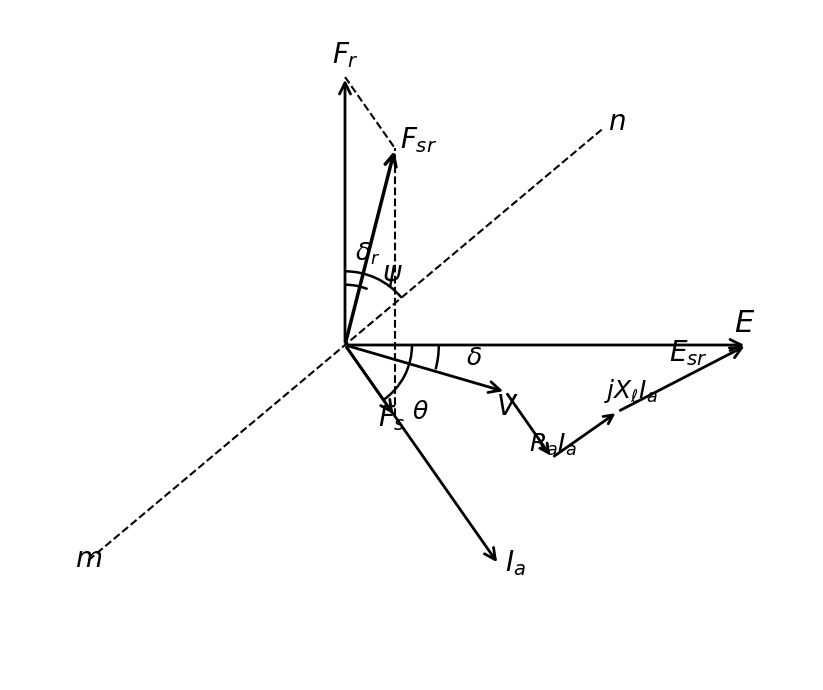

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

fig, ax = plt.subplots(figsize=(10,7))

ax.set_aspect('equal')
ax.axis('off')

O = np.array([0.0, 0.0])

# =====================================================
# MMF-DIAGRAM
# =====================================================
# =====================================================
# MMF-DIAGRAM
# =====================================================

Fr = np.array([0, 4.0])

theta = np.radians(-55)

# Mindre Fs som i referansefiguren
Fs_mag = 1.3

Fs = Fs_mag * np.array([
    np.cos(theta),
    np.sin(theta)
])

Fsr = Fr + Fs

# Fr
ax.add_patch(
    FancyArrowPatch(
        O, Fr,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

ax.text(
    Fr[0]-0.2,
    Fr[1]+0.2,
    r'$F_r$',
    fontsize=20
)

# Fs
ax.add_patch(
    FancyArrowPatch(
        O, Fs,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

ax.text(
    Fs[0]-0.25,
    Fs[1]-0.15,
    r'$F_s$',
    fontsize=20
)

# Fsr = Fr + Fs
ax.add_patch(
    FancyArrowPatch(
        O, Fsr,
        arrowstyle='->',
        mutation_scale=20,
        lw=2.5
    )
)

ax.text(
    Fsr[0]+0.08,
    Fsr[1],
    r'$F_{sr}$',
    fontsize=20
)

# Konstruksjonslinjer
ax.plot(
    [Fsr[0], Fsr[0]],
    [Fs[1], Fsr[1]],
    'k--',
    lw=1.5
)

ax.plot(
    [Fr[0], Fsr[0]],
    [Fr[1], Fsr[1]],
    'k--',
    lw=1.5
)
# =====================================================
# Normalakse n
# =====================================================

n_angle = np.radians(40)

n_end = 5*np.array([
    np.cos(n_angle),
    np.sin(n_angle)
])

m_end = -5*np.array([
    np.cos(n_angle),
    np.sin(n_angle)
])

ax.plot(
    [m_end[0], n_end[0]],
    [m_end[1], n_end[1]],
    'k--',
    lw=1.5
)

ax.text(
    n_end[0]+0.1,
    n_end[1],
    r'$n$',
    fontsize=20
)

ax.text(
    m_end[0]-0.2,
    m_end[1]-0.1,
    r'$m$',
    fontsize=20
)

# =====================================================
# Vinkler
# =====================================================

ax.add_patch(
    Arc(
        (0,0),
        1.8,
        1.8,
        theta1=90-22,
        theta2=90,
        lw=1.8
    )
)

ax.text(
    0.15,
    1.25,
    r'$\delta_r$',
    fontsize=18
)

ax.add_patch(
    Arc(
        (0,0),
        2.2,
        2.2,
        theta1=40,
        theta2=90,
        lw=1.8
    )
)

ax.text(
    0.55,
    0.95,
    r'$\psi$',
    fontsize=20
)

# =====================================================
# SPENNINGSDIAGRAM
# =====================================================

# E langs horisontalakse

E = np.array([6.0,0])

ax.add_patch(
    FancyArrowPatch(
        O,E,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

ax.text(
    E[0]-0.2,
    E[1]+0.2,
    r'$E$',
    fontsize=22
)

# V

V = np.array([2.4,-0.7])

ax.add_patch(
    FancyArrowPatch(
        O,V,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

ax.text(
    V[0]-0.15,
    V[1]-0.35,
    r'$V$',
    fontsize=20
)

# RaIa

RaIa = 1.2*np.array([
    np.cos(theta),
    np.sin(theta)
])

P1 = V
P2 = P1 + RaIa

ax.add_patch(
    FancyArrowPatch(
        P1,P2,
        arrowstyle='->',
        mutation_scale=16,
        lw=2
    )
)

ax.text(
    (P1[0]+P2[0])/2,
    (P1[1]+P2[1])/2 -0.4,
    r'$R_a I_a$',
    fontsize=18
)

# jXlIa

jxl = np.array([
    -RaIa[1],
     RaIa[0]
])

jxl = 1.0*jxl/np.linalg.norm(jxl)

P3 = P2 + 1.2*jxl

ax.add_patch(
    FancyArrowPatch(
        P2,P3,
        arrowstyle='->',
        mutation_scale=16,
        lw=2
    )
)

ax.text(
    P3[0]-0.2,
    P3[1]+0.2,
    r'$jX_\ell I_a$',
    fontsize=18
)

# Ear = Esr

Ear = E - P3

ax.add_patch(
    FancyArrowPatch(
        P3,E,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

mid = (P3+E)/2

ax.text(
    mid[0]-0.2,
    mid[1]+0.25,
    r'$E_{sr}$',
    fontsize=20
)

# -----------------------------------------------------
# Ia
# -----------------------------------------------------

Ia = 4*np.array([
    np.cos(theta),
    np.sin(theta)
])

ax.add_patch(
    FancyArrowPatch(
        O,Ia,
        arrowstyle='->',
        mutation_scale=20,
        lw=2
    )
)

ax.text(
    Ia[0]+0.1,
    Ia[1]-0.1,
    r'$I_a$',
    fontsize=20
)

# -----------------------------------------------------
# theta
# -----------------------------------------------------

ax.add_patch(
    Arc(
        (0,0),
        2,
        2,
        theta1=-55,
        theta2=0,
        lw=1.8
    )
)

ax.text(
    1.0,
    -1.1,
    r'$\theta$',
    fontsize=18
)

# -----------------------------------------------------
# delta
# -----------------------------------------------------

ax.add_patch(
    Arc(
        (0,0),
        2.8,
        2.8,
        theta1=-15,
        theta2=0,
        lw=1.8
    )
)

ax.text(
    1.8,
    -0.3,
    r'$\delta$',
    fontsize=18
)

ax.set_xlim(-5,7)
ax.set_ylim(-5,5)

plt.tight_layout()
plt.show()

### Elektrisk representasjon

Armaturreaksjonens virkning kan representeres elektrisk ved

$$
E_{ar}=jX_{ar}I_a,
$$

der $X_{ar}$ er armaturreaksjonsreaktansen.

Krefter som påvirker hverandre
$$
F_r \leftrightarrow E
$$

$$
F_s \leftrightarrow E_{ar}
$$

$$
F_{sr} \leftrightarrow E_{sr}.
$$

Dette leder til den velkjente synkronreaktansmodellen

$$
E = V_t + jX_sI_a,
$$

der

$$
X_s=X_{ar}+X_l,
$$

og $X_l$ er lekkreaktansen som representerer lekkfluks som ikke følger hovedfluksbanen gjennom luftgapet.


### Over- og undereksitasjon

Eksitasjonsstrømmen $I_f$ bestemmer størrelsen på rotor-MMF-en $F_r$ og dermed den interne genererte spenningen $E$.

- **Overeksitert generator:** $E > V_t$, generatoren leverer reaktiv effekt $Q>0$.
- **Undereksitert generator:** $E < V_t$, generatoren absorberer reaktiv effekt $Q<0$.

Mens eksitasjonen bestemmer $F_r$, bestemmes retningen til $F_s$ av armaturstrømmen $I_a$, som igjen avhenger av lastens effektfaktor.

Dermed er reaktiv effekt et resultat av samspillet mellom rotor-MMF-en $F_r$ og stator-MMF-en $F_s$.